# Modul 5 Inversi

Grid Search

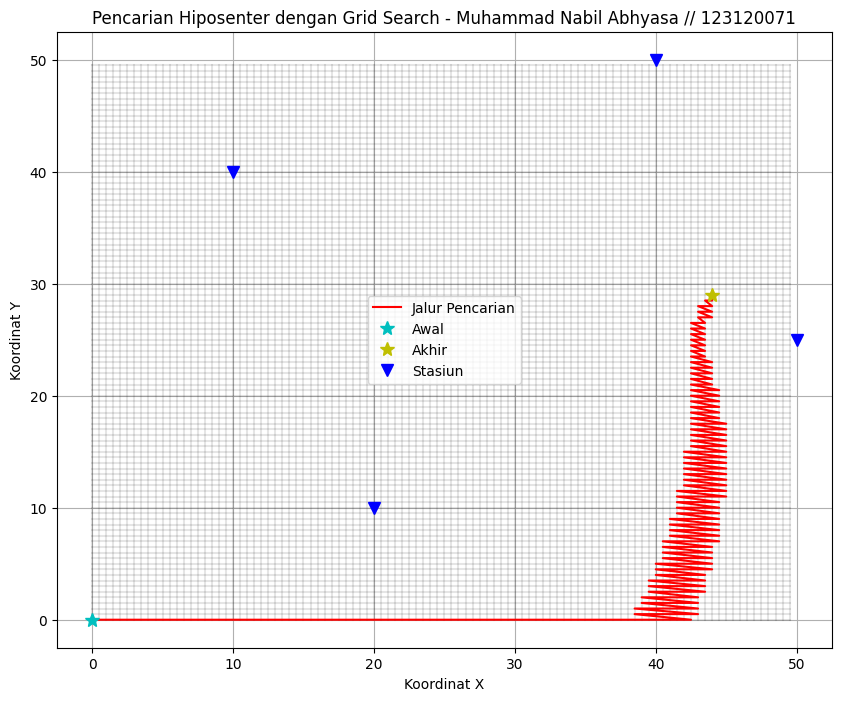

Koordinat X Hiposenter : 44.0
Koordinat Y Hiposenter : 29.0
Nilai Misfit Minimum   : 0.21882594866393357
Jumlah Iterasi: 441


In [13]:
import numpy as np
import matplotlib.pyplot as plt

Vavg = 4.5                                    #Velocity
tobs = [7.1, 1.8, 5.0, 7.9]                 #Waktu Observasi  

Ksts = [20, 50, 40, 10]                     #koordinat X stasiun
Ysts = [10, 25, 50, 40]                     #koordinat y stasiun

# Grid
L = 0.5                                     #jarak antar grid 
X0 = np.arange(0, 50, L)                    #rentang koordinat X
Y0 = np.arange(0, 50, L)                    #rentang koordinay y

# Grid search
P = 10                                      #nilai awal tasiiran misfit
HypoX = []                                  #posisi hiposenter x
HypoY = []

for i in range(len(Y0)):
    for j in range(len(X0)):
        Dt = []                             #nilai objektif
        for k in range(len(Ksts)):        
            tcal = np.sqrt((X0[j]-Ksts[k])**2 + (Y0[i]-Ysts[k])**2) / Vavg      #Menghitung waktu perjalanan teoritis tcal dari titik grid ke stasiun k
            Dt.append((tobs[k] - tcal)**2)                                      #Menambahkan selisih kuadrat antara waktu observasi dan waktu teoritis ke Dt.


        misfit = np.sqrt(np.mean(Dt))       #Menghitung misfit

        if misfit < P:                      #Jika misfit lebih kecil dari nilai minimum saat ini, perbarui posisi hiposenter dan nilai minimum misfit
            HypoX.append(X0[j])             #Menambahkan posisi hiposenter x ke daftar
            HypoY.append(Y0[i])             #Menambahkan posisi hiposenter y ke daftar
            P = misfit                      #Memperbarui nilai minimum misfit

# Plot
plt.figure(figsize=(10, 8))                 #Membuat figure dengan ukuran 10x8 inci

# Grid
for x in X0:
    plt.plot([x, x], [Y0[0], Y0[-1]], 'k-', alpha=0.1)      #Menggambar garis vertikal pada setiap koordinat X dengan transparansi 0.1    

for y in Y0:                                                #Menggambar garis horizontal pada setiap koordinat Y dengan transparansi 0.1    
    plt.plot([X0[0], X0[-1]], [y, y], 'k-', alpha=0.1)      #Menggambar garis horizontal pada setiap koordinat Y dengan transparansi 0.1

# Jalur pencarian
plt.plot(HypoX, HypoY, '-r', label='Jalur Pencarian')                       #Menggambar jalur pencarian hiposenter dengan garis merah
plt.plot(HypoX[0], HypoY[0], '*c', markersize=10, label='Awal')             #Menandai posisi awal hiposenter dengan simbol bintang cyan
plt.plot(HypoX[-1], HypoY[-1], '*y', markersize=10, label='Akhir')          #Menandai posisi akhir hiposenter dengan simbol bintang kuning

# Stasiun   
plt.plot(Ksts, Ysts, 'v', markersize=8, color='blue', label='Stasiun')      #Menandai posisi stasiun dengan simbol segitiga terbalik berwarna biru

# Label
plt.xlabel('Koordinat X')                                                                       #Memberikan label pada sumbu X dengan teks "Koordinat X"
plt.ylabel('Koordinat Y')                                                                       #Memberikan label pada sumbu Y dengan teks "Koordinat Y"                                           
plt.title('Pencarian Hiposenter dengan Grid Search - Muhammad Nabil Abhyasa // 123120071')      #Memberikan judul pada plot dengan teks "Pencarian Hiposenter dengan Grid Search - Muhammad Nabil Abhyasa // 123120071"
plt.legend()                                                                                    #Menampilkan legenda pada plot untuk membedakan antara jalur pencarian, posisi awal, posisi akhir, dan stasiun
plt.grid(True)                                                                                  #Menampilkan grid pada plot

plt.show()                                                                                      #Menampilkan plot yang telah dibuat

#Output
# Output Hasil
print('Koordinat X Hiposenter :', HypoX[-1])                                                    #Menampilkan koordinat X hiposenter yang ditemukan pada iterasi terakhir
print('Koordinat Y Hiposenter :', HypoY[-1])                                                    #Menampilkan koordinat Y hiposenter yang ditemukan pada iterasi terakhir                                
print('Nilai Misfit Minimum   :', P)                                                            #Menampilkan nilai misfit minimum yang ditemukan                                
print('Jumlah Iterasi:', len(HypoX))                                                            #Menampilkan jumlah iterasi yang dilakukan dalam pencarian hiposenter                               

Monte Carlo

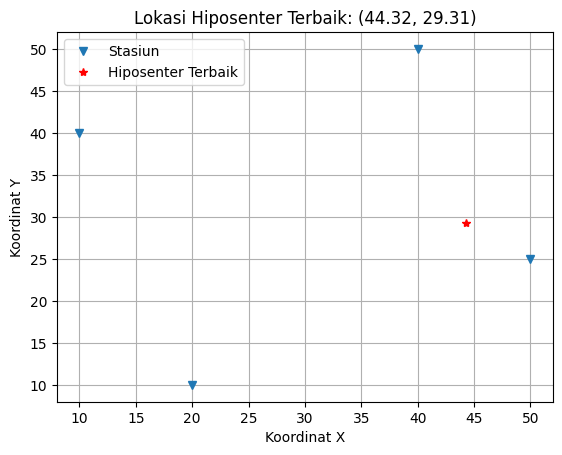

Lokasi Hiposenter Terbaik: (44.32, 29.31)
Misfit Terbaik: 0.22


In [ ]:
#monte carlo
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

Vavg = 4.5                                                                        #kecepatan rata-rata gelombang
tobs = [7.1,1.8,5.0,7.9]                                                        #waktu observasi

#tobs = np.reshape(tobs,(len(tobs),1))
Ksts = [20,50,40,10]                                                            #koordinat x stasiun
Ysts = [10,25,50,40]                                                            #koordinat y stasiun

# Tebakan awal
xo_initial = 12                                                                 # Koordinat X awal
yo_initial = 10                                                                 # Koordinat Y awal

# Fungsi untuk menghitung waktu kalkulasi (tcal)
def calculate_tcal(xo, yo, xsts, ysts, vavg):                                   #Menghitung waktu kalkulasi (tcal) berdasarkan koordinat hiposenter (xo, yo), koordinat stasiun (xsts, ysts), dan kecepatan rata-rata (vavg)
    return np.sqrt((xsts - xo)**2 + (ysts - yo)**2) / vavg                      #Menghitung waktu kalkulasi (tcal) menggunakan rumus jarak dibagi kecepatan 

# Fungsi untuk menghitung error (misfit)
def calculate_misfit(tobs, tcal):                                               #Menghitung misfit antara waktu observasi (tobs) dan waktu kalkulasi (tcal)
    tobs = np.array(tobs)                                                       #Mengubah tobs menjadi array numpy untuk perhitungan yang lebih mudah
    tcal = np.array(tcal)                                                       #Mengubah tcal menjadi array numpy untuk perhitungan yang lebih mudah
    return np.sqrt(np.mean((tobs - tcal)**2))                                   #Menghitung misfit menggunakan akar dari rata-rata selisih kuadrat antara tobs dan tcal

# Inisialisasi variabel
best_xo = xo_initial                                                            # Menyimpan koordinat X terbaik yang ditemukan                  
best_yo = yo_initial                                                            # Menyimpan koordinat Y terbaik yang ditemukan                          
best_misfit = float('inf')                                                      #Inisialisasi misfit terbaik dengan nilai tak hingga                      
n_iterations = 666                                                              #jumlah iterasi monte carlo

#lakukan pencarian acak (monte carlo)
for _ in range(n_iterations):
   # Buat tebakan acak untuk koordinat hiposenter
    xo_random = np.random.uniform(0, 50)                                        # Membuat tebakan acak untuk koordinat X hiposenter dalam rentang 0 hingga 50                                                                
    yo_random = np.random.uniform(0, 50)                                        # Membuat tebakan acak untuk koordinat Y hiposenter dalam rentang 0 hingga 50

    # Hitung waktu kalkulasi untuk tebakan acak
    tcal_random = [calculate_tcal(xo_random, yo_random, xsts, ysts, Vavg) for xsts, ysts in zip(Ksts, Ysts)]          # Menghitung waktu kalkulasi (tcal) untuk setiap stasiun menggunakan tebakan acak koordinat hiposenter                                         

    # Hitung misfit untuk tebakan acak
    misfit_random = calculate_misfit(tobs, tcal_random)                          # Menghitung misfit untuk tebakan acak menggunakan fungsi calculate_misfit

    # Perbarui model jika misfit lebih kecil
    if misfit_random < best_misfit:                                              # Jika misfit untuk tebakan acak lebih kecil dari misfit terbaik saat ini, perbarui koordinat hiposenter terbaik dan nilai misfit terbaik                                                                                                           
        best_xo = xo_random                                                      # Memperbarui koordinat X terbaik dengan tebakan acak yang baru ditemukan                             
        best_yo = yo_random                                                      # Memperbarui koordinat Y terbaik dengan tebakan acak yang baru ditemukan               
        best_misfit = misfit_random                                              # Memperbarui nilai misfit terbaik dengan misfit dari tebakan acak yang baru ditemukan      
# Plot hasil akhir
plt.plot(Ksts, Ysts, 'v', label='Stasiun')                                       #Menandai posisi stasiun dengan simbol segitiga terbalik   
plt.plot(best_xo, best_yo, '*r', label='Hiposenter Terbaik')                     #Menandai posisi hiposenter terbaik yang ditemukan dengan simbol bintang merah
plt.xlabel('Koordinat X')                                                        #Memberikan label pada sumbu X dengan teks "Koordinat X"
plt.ylabel('Koordinat Y')                                                        #Memberikan label pada sumbu Y dengan teks "Koordinat Y"
plt.legend()                                                                     #Menampilkan legenda pada plot untuk membedakan antara stasiun dan hiposenter terbaik
plt.title(f'Lokasi Hiposenter Terbaik: ({best_xo:.2f}, {best_yo:.2f})')          #Memberikan judul pada plot dengan informasi lokasi hiposenter terbaik yang ditemukan
plt.grid(True)                                                                   #Menampilkan grid pada plot 
plt.show()                                                                       #Menampilkan plot yang telah dibuat

print(f"Lokasi Hiposenter Terbaik: ({best_xo:.2f}, {best_yo:.2f})")              #Menampilkan lokasi hiposenter terbaik yang ditemukan dengan format koordinat (X, Y) dengan dua angka desimal
print(f"Misfit Terbaik: {best_misfit:.2f}")                                      #Menampilkan nilai misfit terbaik yang ditemukan dengan format angka desimal dengan dua angka di belakang koma                           

TUGAS LS
GRID SEARCH -> NILAI MISSFIT < 0.37,
MONTE CARLO -> NILAI MISSFIT <0.38

Hasil inversi menunjukkan bahwa lokasi hiposenter berada di sekitar koordinat (44, 29), dengan konsistensi antara metode grid search dan Monte Carlo sehingga solusi dapat dianggap cukup stabil. Pola jalur pencarian pada grid search memperlihatkan konvergensi menuju area tersebut, meskipun metode ini kurang efisien karena melakukan pencarian menyeluruh. Sementara itu, Monte Carlo mampu menemukan solusi optimal dengan lebih cepat melalui sampling acak. Posisi hiposenter yang berada di sekitar sebaran stasiun menunjukkan hasil yang masuk akal, namun kualitas solusi masih dapat dipengaruhi oleh distribusi stasiun yang tidak sepenuhnya simetris serta kemungkinan adanya data waktu observasi yang kurang konsisten.

<div style="text-align: center; font-family: 'Times New Roman', Times, serif;">
    <h1>Lampiran</h1>
</div>




<div style="font-family: 'Times New Roman', Times, serif; margin: 20px auto; width: 50%;">
    <p style="text-align: center;">
    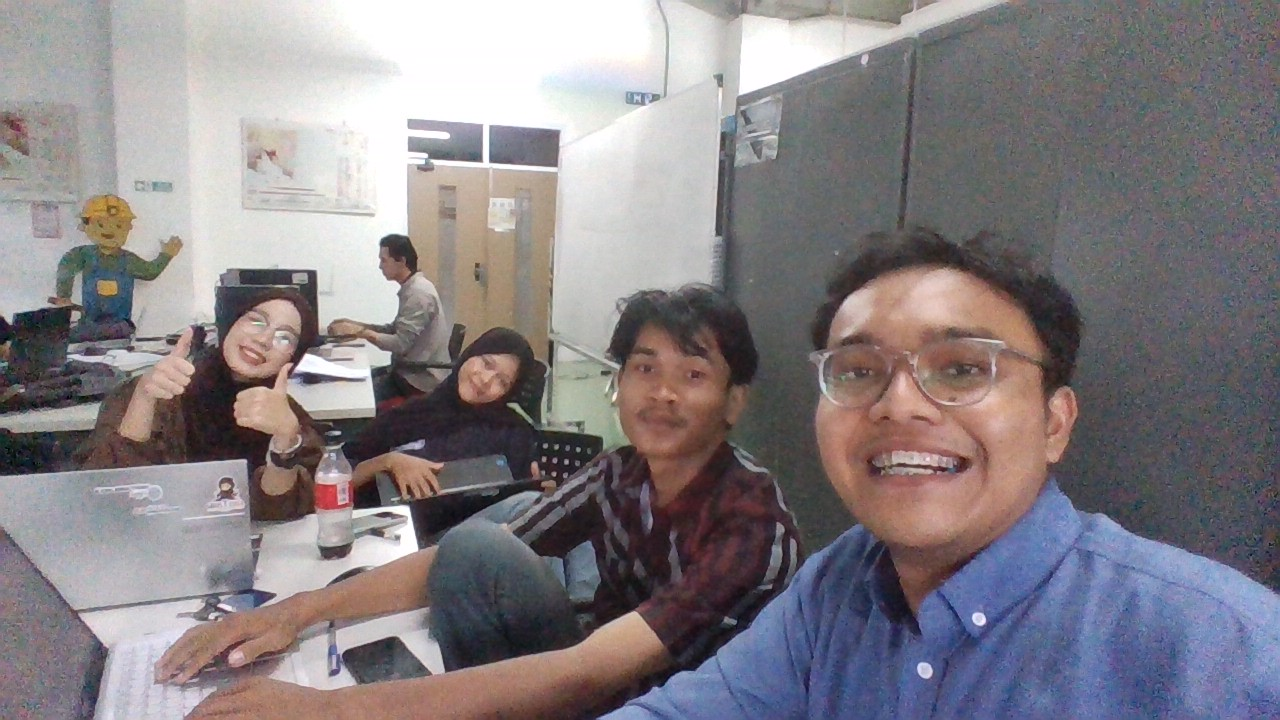